# Comparison Notebook

This notebook regenerates the retained manuscript and supplementary comparison assets from the same dataset and matrix sources used by main.ipynb.

Output policy:
- Export only CSV and PDF assets directly into docs/DCHE-D-26-00020.
- Do not persist analysis/training artifacts to results/.

In [ ]:
import subprocess
import sys
from pathlib import Path
import tomllib


def find_repo_root(start_path: Path) -> Path:
    for candidate in (start_path, *start_path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate pyproject.toml from the current working directory.")


def ensure_pip_available() -> None:
    pip_check_command = [sys.executable, "-m", "pip", "--version"]
    pip_check_result = subprocess.run(
        pip_check_command,
        capture_output=True,
        text=True,
    )
    if pip_check_result.returncode == 0:
        return

    print("pip is not available in this interpreter. Bootstrapping pip with ensurepip...")
    subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"], check=True)

    pip_check_result = subprocess.run(
        pip_check_command,
        capture_output=True,
        text=True,
    )
    if pip_check_result.returncode != 0:
        details = pip_check_result.stderr.strip() or pip_check_result.stdout.strip()
        raise RuntimeError(
            "pip is still unavailable after ensurepip completed. "
            f"Interpreter: {sys.executable}. Details: {details}"
        )


repo_root = find_repo_root(Path.cwd().resolve())
pyproject_path = repo_root / "pyproject.toml"
pyproject = tomllib.loads(pyproject_path.read_text(encoding="utf-8"))

project_config = dict(pyproject.get("project", {}))
dependencies = list(project_config.get("dependencies", []))
if not dependencies:
    raise ValueError(f"No project.dependencies entries were found in {pyproject_path}")

uv_config = dict(pyproject.get("tool", {}).get("uv", {}))
extra_index_urls = list(
    dict.fromkeys(
        entry["url"]
        for entry in uv_config.get("index", [])
        if isinstance(entry, dict) and entry.get("url")
    )
)

ensure_pip_available()

install_command = [sys.executable, "-m", "pip", "install", "--upgrade"]
for index_url in extra_index_urls:
    install_command.extend(["--extra-index-url", index_url])
install_command.extend(dependencies)

print(f"Installing {len(dependencies)} dependencies from {pyproject_path.name}.")
print(f"Python executable: {sys.executable}")
if project_config.get("requires-python"):
    print(f"Project requires Python {project_config['requires-python']}")
if extra_index_urls:
    print("Using additional package indexes:")
    for index_url in extra_index_urls:
        print(f"- {index_url}")

subprocess.run(install_command, check=True, cwd=repo_root)

print("Dependency installation complete.")
print("Restart the kernel if any newly installed packages are not immediately available.")

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as ipython_display
from scipy.linalg import null_space

from src.models.ml import (
    load_adaboost_regressor_params,
    load_ann_deep_regressor_params,
    load_catboost_regressor_params,
    load_icsor_params,
    load_knn_regressor_params,
    load_lightgbm_regressor_params,
    load_pls_regressor_params,
    load_random_forest_regressor_params,
    load_svr_regressor_params,
    load_xgboost_regressor_params,
    run_adaboost_regressor_pipeline,
    run_ann_deep_regressor_pipeline,
    run_catboost_regressor_pipeline,
    run_icsor_pipeline,
    run_knn_regressor_pipeline,
    run_lightgbm_regressor_pipeline,
    run_pls_regressor_pipeline,
    run_random_forest_regressor_pipeline,
    run_svr_regressor_pipeline,
    run_xgboost_regressor_pipeline,
)
from src.models.ml.adaboost_regressor import build_adaboost_regressor_model
from src.models.ml.ann_deep_regressor import build_ann_deep_regressor_model
from src.models.ml.catboost_regressor import build_catboost_regressor_model
from src.models.ml.knn_regressor import build_knn_regressor_model
from src.models.ml.lightgbm_regressor import build_lightgbm_regressor_model
from src.models.ml.pls_regressor import build_pls_regressor_model
from src.models.ml.random_forest_regressor import build_random_forest_regressor_model
from src.models.ml.svr_regressor import build_svr_regressor_model
from src.models.ml.xgboost_regressor import build_xgboost_regressor_model
from src.models.simulation.asm2d_tsn_simulation import get_asm2d_tsn_matrices, load_asm2d_tsn_simulation_params
from src.utils.analysis import (
    add_effective_metric_columns,
    collate_model_analysis_results,
    rank_metric_summary,
    run_model_dataset_size_analysis,
    summarize_metric_distribution,
)
from src.utils.plot import (
    PIBRE_THEME_TOKENS,
    plot_coefficient_heatmap,
    plot_icsor_target_atlas,
    plot_metric_summary_lines,
    save_figure_pdf,
)
from src.utils.process import (
    apply_train_test_split_indices,
    build_fractional_input_fractional_output_dataset,
    build_icsor_supervised_dataset,
    make_train_test_split_indices,
    sample_dataset_split_indices,
)
from src.utils.simulation import get_repo_root, load_ml_orchestration_params
from src.utils.train import tune_icsor_hyperparameters, tune_tabular_regressor_hyperparameters

repo_root = get_repo_root()
paths_config = json.loads((repo_root / "config" / "paths.json").read_text(encoding="utf-8"))
submission_asset_dir = repo_root / paths_config["submission_asset_dir"]
submission_asset_dir.mkdir(parents=True, exist_ok=True)

comparison_table_pattern = paths_config["comparison_notebook_table_pattern"]
comparison_figure_pattern = paths_config["comparison_notebook_figure_pattern"]

required_assets = [
    "table_results_benchmark_sample.csv",
    "table_results_target_sample.csv",
    "figure2_rmse_learning_curve.pdf",
    "table_results_scaling_sample.csv",
    "figure3_runtime_learning_curve.pdf",
    "table_results_physical_sample.csv",
    "figure4_icsor_structure.pdf",
    "table_results_icsor_regularization_sample.csv",
    "figureS1_cod_icsor_structure.pdf",
    "figureS2_tn_icsor_structure.pdf",
    "figureS3_tp_icsor_structure.pdf",
    "figureS4_tss_icsor_structure.pdf",
]

print(f"Submission asset directory: {submission_asset_dir}")
print(f"Comparison table pattern: {comparison_table_pattern}")
print(f"Comparison figure pattern: {comparison_figure_pattern}")
print(f"Expected asset count: {len(required_assets)}")

c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Submission asset directory: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020
Comparison table pattern: docs/DCHE-D-26-00020/{artifact_name}.csv
Comparison figure pattern: docs/DCHE-D-26-00020/{artifact_name}.pdf
Expected asset count: 12


In [2]:
analysis_metric = "projected_MSE"

ml_orchestration_params = load_ml_orchestration_params()
ml_orchestration = dict(ml_orchestration_params["hyperparameters"])
analysis_settings = dict(ml_orchestration_params.get("analysis", {}))
benchmark_settings = dict(ml_orchestration_params.get("benchmark", {}))
USE_OPTUNA = bool(benchmark_settings.get("use_optuna", False))

configured_analysis_overrides = {
    "min_total_samples": int(analysis_settings.get("min_total_samples", 500)),
    "max_total_samples": int(analysis_settings.get("max_total_samples", 10000)),
    "total_sample_step": int(analysis_settings.get("total_sample_step", 950)),
    "n_repeats": int(analysis_settings.get("n_repeats", 100)),
    "test_fraction": float(analysis_settings.get("test_fraction", ml_orchestration.get("test_fraction", 0.2))),
    "random_seed": int(ml_orchestration.get("random_seed", 42)),
}

FAST_E2E_TEST = True
fast_test_analysis_overrides = {
    "min_total_samples": 40,
    "max_total_samples": 120,
    "total_sample_step": 40,
    "n_repeats": 2,
    "test_fraction": float(ml_orchestration.get("test_fraction", 0.2)),
    "random_seed": int(ml_orchestration.get("random_seed", 42)),
}
analysis_overrides = fast_test_analysis_overrides if FAST_E2E_TEST else configured_analysis_overrides

print(f"Classical benchmark Optuna enabled: {USE_OPTUNA}")
print(f"Analysis metric set to: {analysis_metric}")
print(f"Fast end-to-end test mode: {FAST_E2E_TEST}")
print("Repeated-size analysis overrides:")
for key, value in analysis_overrides.items():
    print(f"- {key}: {value}")

Classical benchmark Optuna enabled: False
Analysis metric set to: projected_MSE
Fast end-to-end test mode: True
Repeated-size analysis overrides:
- min_total_samples: 40
- max_total_samples: 120
- total_sample_step: 40
- n_repeats: 2
- test_fraction: 0.2
- random_seed: 42


In [3]:
repo_root = get_repo_root()
simulation_dir = repo_root / "data" / "asm2d-tsn" / "simulation"

dataset_candidates = {
    path.stem.removeprefix("data_"): path
    for path in simulation_dir.glob("data_*.csv")
}
metadata_candidates = {
    path.stem.removeprefix("metadata_"): path
    for path in simulation_dir.glob("metadata_*.json")
}

if not dataset_candidates:
    raise FileNotFoundError(f"No ASM2D-TSN datasets found in {simulation_dir}")
if not metadata_candidates:
    raise FileNotFoundError(f"No ASM2D-TSN metadata files found in {simulation_dir}")

shared_timestamps = sorted(set(dataset_candidates) & set(metadata_candidates))
if shared_timestamps:
    latest_timestamp = shared_timestamps[-1]
    latest_dataset_path = dataset_candidates[latest_timestamp]
    latest_metadata_path = metadata_candidates[latest_timestamp]
else:
    latest_dataset_path = max(dataset_candidates.values(), key=lambda path: path.stat().st_mtime)
    latest_metadata_path = max(metadata_candidates.values(), key=lambda path: path.stat().st_mtime)

dataset = pd.read_csv(latest_dataset_path)
metadata = json.loads(latest_metadata_path.read_text(encoding="utf-8-sig"))
artifact_paths = {
    "dataset_csv": latest_dataset_path,
    "metadata_json": latest_metadata_path,
}

model_params = load_asm2d_tsn_simulation_params(repo_root)
matrix_bundle = get_asm2d_tsn_matrices(model_params, repo_root=repo_root)
state_columns = list(matrix_bundle["state_columns"])
measured_output_columns = list(matrix_bundle["measured_output_columns"])
petersen_matrix = np.asarray(matrix_bundle["petersen_matrix"], dtype=float)
composition_matrix = np.asarray(matrix_bundle["composition_matrix"], dtype=float)

metadata_state_columns = list(metadata.get("state_columns", []))
metadata_measured_output_columns = list(metadata.get("measured_output_columns", []))
if metadata_state_columns and metadata_state_columns != state_columns:
    raise ValueError(
        "Metadata state_columns do not match workbook-derived state columns. Regenerate simulation artifacts."
    )
if metadata_measured_output_columns and metadata_measured_output_columns != measured_output_columns:
    raise ValueError(
        "Metadata measured_output_columns do not match workbook composition_matrix columns. Regenerate simulation artifacts."
    )

print(f"Loaded {len(dataset)} rows for {metadata['simulation_name']}.")
print(f"Dataset loaded from: {artifact_paths['dataset_csv']}")
print(f"Metadata loaded from: {artifact_paths['metadata_json']}")
print(f"Matrix source: {matrix_bundle['composition_workbook_path']}")
print(f"Composition cache source: {matrix_bundle['composition_cache_source']}")
print(f"Petersen matrix shape: {petersen_matrix.shape}")
print(f"Composition matrix shape: {composition_matrix.shape}")

ipython_display(dataset.head())

Loaded 120 rows for asm2d_tsn_simulation.
Dataset loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tsn\simulation\data_20260422_120000.csv
Metadata loaded from: C:\Users\eselerio\projects\pibre-model\data\asm2d-tsn\simulation\metadata_20260422_120000.json
Matrix source: C:/Users/eselerio/projects/pibre-model/data/asm2d-tsn/asm2d_tsn_workbook.xlsx
Composition cache source: cache
Petersen matrix shape: (28, 20)
Composition matrix shape: (4, 20)


,HRT,Aeration,In_S_O,In_S_F,In_S_A,In_S_NH4,In_S_NO2,In_S_NO3,In_S_N2,In_S_PO4,...,Out_X_PP,Out_X_PHA,Out_X_AOB,Out_X_NOB,Out_X_MeP,Out_X_MeOH,Out_COD,Out_TN,Out_TP,Out_TSS
0,33.304536,0.769557,0.096633,24.856112,45.037878,20.205008,0.847323,2.750122,1.331549,13.602139,...,8.055621,15.788761,3.544594,7.571050e+00,12.514621,1.178597,329.364397,29.874916,22.231357,256.386263
1,34.737404,1.781444,0.356728,105.884933,19.757144,31.459997,0.815541,7.123836,1.872135,11.845098,...,8.685990,0.269811,4.375561,1.000000e-08,14.786741,3.553763,352.745905,42.958758,19.903832,308.226114
2,29.031310,2.152360,0.250623,143.366387,59.712617,19.771197,1.115366,3.726128,1.391105,8.036099,...,19.759180,27.693071,6.361204,3.225982e+00,9.407499,2.508384,542.779459,35.567396,31.584582,478.060957
3,34.288016,2.132976,0.185229,65.572587,32.831810,31.426996,2.506980,2.012990,1.439719,14.511533,...,14.236173,1.996190,6.712771,6.522642e+00,5.184674,3.404109,423.805900,47.603582,22.795625,397.746881
4,7.399591,2.085684,0.189963,171.106295,75.317435,35.886877,1.503144,0.192062,1.961602,15.455573,...,7.397960,23.745535,5.592335,7.199851e+00,20.011720,1.053707,473.412175,39.901603,34.102376,349.873925


In [4]:
icsor_constraint_basis = null_space(petersen_matrix)
icsor_A_matrix = icsor_constraint_basis.T

icsor_A_matrix = np.round(icsor_A_matrix, 5)
icsor_A_matrix[np.abs(icsor_A_matrix) < 1e-10] = 0.0

for row_index in range(icsor_A_matrix.shape[0]):
    non_zero_entries = icsor_A_matrix[row_index, icsor_A_matrix[row_index, :] != 0]
    if len(non_zero_entries) > 0:
        icsor_A_matrix[row_index, :] = icsor_A_matrix[row_index, :] / non_zero_entries[0]

A_matrix = icsor_A_matrix.copy()

print(f"Fractional Petersen matrix shape: {petersen_matrix.shape}")
print(f"Invariant matrix shape: {A_matrix.shape}")

Fractional Petersen matrix shape: (28, 20)
Invariant matrix shape: (5, 20)


In [5]:
classical_benchmark_dataset = build_fractional_input_fractional_output_dataset(
    dataset,
    metadata,
    composition_matrix,
)
icsor_dataset = build_icsor_supervised_dataset(
    dataset,
    metadata,
    composition_matrix,
)

shared_split_indices = make_train_test_split_indices(
    dataset.index,
    test_fraction=float(ml_orchestration["test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
main_dataset_splits = apply_train_test_split_indices(
    classical_benchmark_dataset,
    shared_split_indices,
)
icsor_dataset_splits = apply_train_test_split_indices(
    icsor_dataset,
    shared_split_indices,
)

optuna_indices = sample_dataset_split_indices(
    shared_split_indices.train,
    fraction=float(ml_orchestration["optuna_dataset_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
tuning_split_indices = make_train_test_split_indices(
    optuna_indices,
    test_fraction=float(ml_orchestration["optuna_test_fraction"]),
    random_seed=int(ml_orchestration["random_seed"]),
)
tuning_dataset_splits = apply_train_test_split_indices(
    classical_benchmark_dataset,
    tuning_split_indices,
)
icsor_tuning_dataset_splits = apply_train_test_split_indices(
    icsor_dataset,
    tuning_split_indices,
)

print("Split contract ready.")
print(f"Main train size: {len(main_dataset_splits.train.features)}")
print(f"Main test size: {len(main_dataset_splits.test.features)}")
print(f"Optuna train size: {len(tuning_dataset_splits.train.features)}")
print(f"Optuna test size: {len(tuning_dataset_splits.test.features)}")

Split contract ready.
Main train size: 96
Main test size: 24
Optuna train size: 38
Optuna test size: 10


In [ ]:
def comparison_table_path(artifact_name: str) -> Path:
    return repo_root / comparison_table_pattern.format(artifact_name=artifact_name)


def comparison_figure_path(artifact_name: str) -> Path:
    return repo_root / comparison_figure_pattern.format(artifact_name=artifact_name)


def export_table_csv(artifact_name: str, frame: pd.DataFrame, *, index: bool = False) -> Path:
    export_path = comparison_table_path(artifact_name)
    export_path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(export_path, index=index)
    print(f"Saved table: {export_path}")
    return export_path


def export_figure_pdf(artifact_name: str, figure: plt.Figure) -> Path:
    export_path = comparison_figure_path(artifact_name)
    save_figure_pdf(figure, export_path)
    print(f"Saved figure: {export_path}")
    return export_path


retention_fraction = 1e-4

retained_model_specs = {
    "icsor": {
        "label": "ICSOR",
        "family": "Physics-informed",
        "dataset_key": "icsor",
        "load_params": load_icsor_params,
        "runner": run_icsor_pipeline,
        "tune": tune_icsor_hyperparameters,
        "extra_runner_kwargs": {
            "composition_matrix": composition_matrix,
            "measured_output_columns": list(metadata["measured_output_columns"]),
            "composition_source": metadata.get("composition_source"),
        },
    },
    "xgboost_regressor": {
        "label": "XGBoost",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_xgboost_regressor_params,
        "build_model": build_xgboost_regressor_model,
        "runner": run_xgboost_regressor_pipeline,
    },
    "lightgbm_regressor": {
        "label": "LightGBM",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_lightgbm_regressor_params,
        "build_model": build_lightgbm_regressor_model,
        "runner": run_lightgbm_regressor_pipeline,
    },
    "catboost_regressor": {
        "label": "CatBoost",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_catboost_regressor_params,
        "build_model": build_catboost_regressor_model,
        "runner": run_catboost_regressor_pipeline,
    },
    "adaboost_regressor": {
        "label": "AdaBoost",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_adaboost_regressor_params,
        "build_model": build_adaboost_regressor_model,
        "runner": run_adaboost_regressor_pipeline,
    },
    "random_forest_regressor": {
        "label": "Random Forest",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_random_forest_regressor_params,
        "build_model": build_random_forest_regressor_model,
        "runner": run_random_forest_regressor_pipeline,
    },
    "svr_regressor": {
        "label": "SVR",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_svr_regressor_params,
        "build_model": build_svr_regressor_model,
        "runner": run_svr_regressor_pipeline,
    },
    "knn_regressor": {
        "label": "k-NN",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_knn_regressor_params,
        "build_model": build_knn_regressor_model,
        "runner": run_knn_regressor_pipeline,
    },
    "pls_regressor": {
        "label": "PLS",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_pls_regressor_params,
        "build_model": build_pls_regressor_model,
        "runner": run_pls_regressor_pipeline,
    },
    "ann_deep_regressor": {
        "label": "MLP",
        "family": "Classical",
        "dataset_key": "classical",
        "load_params": load_ann_deep_regressor_params,
        "build_model": build_ann_deep_regressor_model,
        "runner": run_ann_deep_regressor_pipeline,
    },
}

print(f"Retained model count: {len(retained_model_specs)}")
print("Retained model labels:")
for spec in retained_model_specs.values():
    print(f"- {spec['label']}")

Retained model count: 10
Retained model labels:
- ICSOR
- XGBoost
- LightGBM
- CatBoost
- AdaBoost
- Random Forest
- SVR
- k-NN
- PLS
- MLP


In [7]:
import time

selected_hyperparameters: dict[str, dict[str, object]] = {}
optuna_summaries: dict[str, dict[str, object] | None] = {}
fixed_split_results: dict[str, dict[str, object]] = {}
fixed_split_runtime_rows: list[dict[str, object]] = []

for model_name, spec in retained_model_specs.items():
    print(f"Running fixed-split benchmark for {spec['label']}...")
    params = spec["load_params"]()
    hyperparameters = dict(params["training_defaults"])
    optuna_summary = None

    if USE_OPTUNA and bool(params.get("search_space")):
        if model_name == "icsor":
            hyperparameters, optuna_summary = spec["tune"](
                icsor_tuning_dataset_splits.train,
                icsor_tuning_dataset_splits.test,
                A_matrix=icsor_A_matrix,
                composition_matrix=composition_matrix,
                measured_output_columns=list(metadata["measured_output_columns"]),
                model_params=params,
                model_hyperparameters=hyperparameters,
                n_trials=int(ml_orchestration["n_trials"]),
                timeout=ml_orchestration.get("timeout_seconds"),
                show_progress_bar=True,
            )
        else:
            hyperparameters, optuna_summary = tune_tabular_regressor_hyperparameters(
                model_name,
                spec["build_model"],
                tuning_dataset_splits.train,
                tuning_dataset_splits.test,
                A_matrix=A_matrix,
                composition_matrix=composition_matrix,
                measured_output_columns=list(metadata["measured_output_columns"]),
                model_params=params,
                n_trials=int(ml_orchestration["n_trials"]),
                timeout=ml_orchestration.get("timeout_seconds"),
                show_progress_bar=True,
            )

    selected_hyperparameters[model_name] = dict(hyperparameters)
    optuna_summaries[model_name] = optuna_summary

    dataset_splits = icsor_dataset_splits if spec["dataset_key"] == "icsor" else main_dataset_splits
    constraint_matrix = icsor_A_matrix if spec["dataset_key"] == "icsor" else A_matrix

    runner_kwargs = {
        "composition_matrix": composition_matrix,
        "measured_output_columns": list(metadata["measured_output_columns"]),
        "repo_root": repo_root,
        "model_params": params,
        "model_hyperparameters": hyperparameters,
        "optuna_summary": optuna_summary,
        "persist_artifacts": False,
        "show_progress": False,
    }
    runner_kwargs.update(dict(spec.get("extra_runner_kwargs", {})))

    run_started_at = time.perf_counter()
    result = spec["runner"](
        dataset_splits.train,
        dataset_splits.test,
        constraint_matrix,
        **runner_kwargs,
    )
    run_elapsed_seconds = float(time.perf_counter() - run_started_at)

    fixed_split_results[model_name] = result
    fixed_split_runtime_rows.append(
        {
            "model_name": model_name,
            "model_label": spec["label"],
            "runtime_seconds": run_elapsed_seconds,
        }
    )

fixed_split_runtime_summary = pd.DataFrame(fixed_split_runtime_rows).sort_values("model_label").reset_index(drop=True)
print("Fixed-split benchmark complete for retained models.")
ipython_display(fixed_split_runtime_summary)

Running fixed-split benchmark for ICSOR...
Running fixed-split benchmark for XGBoost...
Running fixed-split benchmark for LightGBM...
Running fixed-split benchmark for CatBoost...
Running fixed-split benchmark for AdaBoost...
Running fixed-split benchmark for Random Forest...
Running fixed-split benchmark for SVR...
Running fixed-split benchmark for k-NN...
Running fixed-split benchmark for PLS...
Running fixed-split benchmark for MLP...
Fixed-split benchmark complete for retained models.


c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,model_name,model_label,runtime_seconds
0,adaboost_regressor,AdaBoost,4.303843
1,catboost_regressor,CatBoost,0.923640
2,icsor,ICSOR,0.847383
3,lightgbm_regressor,LightGBM,1.379830
4,ann_deep_regressor,MLP,1.057005
5,pls_regressor,PLS,0.079408
6,random_forest_regressor,Random Forest,0.412378
7,svr_regressor,SVR,0.124237
8,xgboost_regressor,XGBoost,1.822025
9,knn_regressor,k-NN,0.121224


In [8]:
analysis_results_by_model: dict[str, dict[str, object]] = {}

for model_name, spec in retained_model_specs.items():
    print(f"Running repeated-size analysis for {spec['label']}...")

    dataset = icsor_dataset if spec["dataset_key"] == "icsor" else classical_benchmark_dataset
    constraint_matrix = icsor_A_matrix if spec["dataset_key"] == "icsor" else A_matrix

    runner_kwargs = {
        "composition_matrix": composition_matrix,
        "measured_output_columns": list(metadata["measured_output_columns"]),
    }
    runner_kwargs.update(dict(spec.get("extra_runner_kwargs", {})))

    analysis_result = run_model_dataset_size_analysis(
        model_name,
        dataset,
        constraint_matrix,
        spec["runner"],
        model_params=spec["load_params"](),
        model_hyperparameters=selected_hyperparameters[model_name],
        repo_root=repo_root,
        show_progress=True,
        show_runner_progress=False,
        persist_artifacts=False,
        include_prediction_tables=False,
        extra_runner_kwargs=runner_kwargs,
        **analysis_overrides,
    )
    analysis_results_by_model[model_name] = analysis_result

print("Repeated-size analysis complete for retained models.")

Running repeated-size analysis for ICSOR...


Analyze icsor: 100%|██████████| 6/6 [00:05<00:00,  1.16run/s, repeat=2, size=120]


Running repeated-size analysis for XGBoost...


Analyze xgboost_regressor: 100%|██████████| 6/6 [00:11<00:00,  1.84s/run, repeat=2, size=120]


Running repeated-size analysis for LightGBM...


...

Running repeated-size analysis for PLS...


Analyze pls_regressor: 100%|██████████| 6/6 [00:00<00:00, 11.42run/s, repeat=2, size=120]


Running repeated-size analysis for MLP...


Analyze ann_deep_regressor:   0%|          | 0/6 [00:00<?, ?run/s]c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
Analyze ann_deep_regressor:  17%|█▋        | 1/6 [00:00<00:01,  2.60run/s, repeat=1, size=40]c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:695: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
c:\Users\eselerio\projects\pibre-model\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceW

Repeated-size analysis complete for retained models.


In [10]:
import importlib
import src.utils.analysis as analysis_module
importlib.reload(analysis_module)
from src.utils.analysis import collate_model_analysis_results

comparison_model_labels = {
    model_name: retained_model_specs[model_name]["label"]
    for model_name in retained_model_specs
}
comparison_model_families = {
    model_name: retained_model_specs[model_name]["family"]
    for model_name in retained_model_specs
}

comparison_bundle = collate_model_analysis_results(
    analysis_results_by_model,
    model_labels=comparison_model_labels,
    model_families=comparison_model_families,
)

comparison_metric_basenames = ["RMSE", "MAE", "R2", "MAPE", "MSE"]
comparison_primary_metric = "effective_RMSE"
comparison_primary_split = "test"
comparison_base_model_columns = ["model_name", "model_label", "model_family", "model_order"]
comparison_run_metadata = comparison_bundle["run_metadata"].copy()
comparison_effective_aggregate_metrics = comparison_bundle["effective_aggregate_metrics"].copy()
comparison_per_target_metrics = comparison_bundle["per_target_metrics"].copy()
comparison_prediction_diagnostics = comparison_bundle["prediction_diagnostics"].copy()
comparison_prediction_target_diagnostics = comparison_bundle["prediction_target_diagnostics"].copy()
comparison_smallest_train_size = int(comparison_run_metadata["train_size"].min())
comparison_largest_train_size = int(comparison_run_metadata["train_size"].max())
comparison_target_labels = [
    str(target_name).removeprefix("Out_")
    for target_name in metadata["measured_output_columns"]
]

print("Comparison bundles derived.")
print(f"Train-size range: {comparison_smallest_train_size} to {comparison_largest_train_size}")
print(f"Primary metric: {comparison_primary_metric}")

Comparison bundles derived.
Train-size range: 32 to 96
Primary metric: effective_RMSE


In [11]:
comparison_test_aggregate_metrics = comparison_effective_aggregate_metrics.loc[
    comparison_effective_aggregate_metrics["split_name"] == "test"
].copy()
comparison_test_per_target_metrics = comparison_per_target_metrics.loc[
    comparison_per_target_metrics["split_name"] == "test"
].copy()

benchmark_rows = []
for model_name, spec in retained_model_specs.items():
    report_metrics = add_effective_metric_columns(fixed_split_results[model_name]["test_report"]["aggregate_metrics"])
    preferred_type = "projected" if "projected" in set(report_metrics["prediction_type"]) else "raw"
    effective_row = report_metrics.loc[report_metrics["prediction_type"] == preferred_type].iloc[0]
    benchmark_rows.append(
        {
            "Model": spec["label"],
            "RMSE": float(effective_row["effective_RMSE"]),
            "MAE": float(effective_row["effective_MAE"]),
            "R2": float(effective_row["effective_R2"]),
            "MAPE": float(effective_row["effective_MAPE"]),
        }
    )

benchmark_table = pd.DataFrame(benchmark_rows).sort_values("RMSE").reset_index(drop=True)
model_display_order = benchmark_table["Model"].tolist()

rmse_target_summary = summarize_metric_distribution(
    comparison_test_per_target_metrics,
    metric_name="effective_RMSE",
    group_columns=[*comparison_base_model_columns, "train_size", "target"],
)
rmse_target_largest = rmse_target_summary.loc[
    rmse_target_summary["train_size"] == comparison_largest_train_size
].copy()
rmse_target_largest["target"] = rmse_target_largest["target"].astype(str).str.removeprefix("Out_")

target_table = (
    rmse_target_largest
    .pivot(index="model_label", columns="target", values="metric_mean")
    .reindex(index=model_display_order, columns=comparison_target_labels)
    .reset_index()
    .rename(columns={"model_label": "Model"})
)

def curve_nauc(summary_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_label, group in summary_frame.groupby("model_label", dropna=False):
        group = group.sort_values("train_size")
        x_values = group["train_size"].to_numpy(dtype=float)
        y_values = group["metric_mean"].to_numpy(dtype=float)
        if len(group) == 1:
            auc_value = float(y_values[0])
        else:
            auc_value = float((np.trapezoid if hasattr(np, "trapezoid") else np.trapz)(y_values, x_values) / (x_values.max() - x_values.min()))
        rows.append({"Model": str(model_label), "RMSE nAUC": auc_value})
    return pd.DataFrame(rows)

rmse_learning_curve_summary = summarize_metric_distribution(
    comparison_test_aggregate_metrics,
    metric_name="effective_RMSE",
    group_columns=[*comparison_base_model_columns, "train_size"],
)
final_rmse_table = (
    rmse_learning_curve_summary.loc[rmse_learning_curve_summary["train_size"] == comparison_largest_train_size]
    .loc[:, ["model_label", "metric_mean"]]
    .rename(columns={"model_label": "Model", "metric_mean": "Final RMSE"})
)
rmse_nauc_table = curve_nauc(rmse_learning_curve_summary)

rank_frames = []
for metric_basename in comparison_metric_basenames:
    metric_name = f"effective_{metric_basename}"
    metric_target_summary = summarize_metric_distribution(
        comparison_test_per_target_metrics,
        metric_name=metric_name,
        group_columns=[*comparison_base_model_columns, "train_size", "target"],
    )
    ranked_frame = rank_metric_summary(
        metric_target_summary,
        group_columns=["train_size", "target"],
        metric_name=metric_name,
    )
    rank_frames.append(
        ranked_frame.groupby(["model_name", "model_label", "model_family", "model_order"], dropna=False)["metric_rank"]
        .mean()
        .reset_index(name=f"{metric_basename}_average_rank")
    )

sample_rank_table = rank_frames[0]
for frame in rank_frames[1:]:
    sample_rank_table = sample_rank_table.merge(
        frame,
        on=["model_name", "model_label", "model_family", "model_order"],
        how="outer",
    )
rank_columns = [f"{metric_basename}_average_rank" for metric_basename in comparison_metric_basenames]
sample_rank_table["Sample Avg. Rank"] = sample_rank_table[rank_columns].mean(axis=1)
sample_rank_table = sample_rank_table.loc[:, ["model_label", "Sample Avg. Rank"]].rename(columns={"model_label": "Model"})

rmse_train_test_summary = summarize_metric_distribution(
    comparison_effective_aggregate_metrics,
    metric_name="effective_RMSE",
    group_columns=[*comparison_base_model_columns, "split_name", "train_size"],
)
rmse_gap_table = (
    rmse_train_test_summary
    .pivot_table(
        index=["model_name", "model_label", "model_family", "model_order", "train_size"],
        columns="split_name",
        values="metric_mean",
        aggfunc="first",
    )
    .reset_index()
)
rmse_gap_table["Delta RMSE"] = rmse_gap_table["test"] - rmse_gap_table["train"]
rmse_gap_largest = (
    rmse_gap_table.loc[rmse_gap_table["train_size"] == comparison_largest_train_size]
    .loc[:, ["model_label", "Delta RMSE"]]
    .rename(columns={"model_label": "Model"})
)

scaling_table = final_rmse_table.merge(rmse_nauc_table, on="Model", how="left")
scaling_table = scaling_table.merge(sample_rank_table, on="Model", how="left")
scaling_table = scaling_table.merge(rmse_gap_largest, on="Model", how="left")
scaling_table["Model"] = pd.Categorical(scaling_table["Model"], categories=model_display_order, ordered=True)
scaling_table = scaling_table.sort_values("Model").reset_index(drop=True)
scaling_table["Model"] = scaling_table["Model"].astype(str)

violation_tolerance = 1e-10
physical_rows = []
for model_name, spec in retained_model_specs.items():
    report = fixed_split_results[model_name]["test_report"]
    fractional_key = "projected_fractional_predictions" if "projected_fractional_predictions" in report else "raw_fractional_predictions"
    constraint_key = "projected_constraint_l2" if "projected_constraint_l2" in report["constraint_residuals"].columns else "raw_constraint_l2"
    fractional_values = report[fractional_key].to_numpy(dtype=float)
    constraint_values = report["constraint_residuals"][constraint_key].to_numpy(dtype=float)
    physical_rows.append(
        {
            "Model": spec["label"],
            "Mass-Conservation Violations (%)": 100.0 * float(np.mean(constraint_values > violation_tolerance)),
            "Non-Negativity Violations (%)": 100.0 * float(np.mean((fractional_values < -violation_tolerance).any(axis=1))),
        }
    )
physical_table = pd.DataFrame(physical_rows)
physical_table["Model"] = pd.Categorical(physical_table["Model"], categories=model_display_order, ordered=True)
physical_table = physical_table.sort_values("Model").reset_index(drop=True)
physical_table["Model"] = physical_table["Model"].astype(str)

icsor_effective_coefficients = fixed_split_results["icsor"]["model_bundle"]["effective_coefficients"]
measured_targets = list(metadata["measured_output_columns"])
cod_target_index = measured_targets.index("COD")

def target_block_values(block_values: np.ndarray, target_index: int) -> np.ndarray:
    values_array = np.asarray(block_values, dtype=float)
    if values_array.ndim == 1:
        return values_array[target_index : target_index + 1]
    return values_array[target_index]

cod_block_arrays = {
    "b": np.asarray(target_block_values(icsor_effective_coefficients["b"], cod_target_index), dtype=float),
    "W_u": np.asarray(target_block_values(icsor_effective_coefficients["W_u"], cod_target_index), dtype=float),
    "W_in": np.asarray(target_block_values(icsor_effective_coefficients["W_in"], cod_target_index), dtype=float),
    "Theta_uu": np.asarray(target_block_values(icsor_effective_coefficients["Theta_uu"], cod_target_index), dtype=float),
    "Theta_uc": np.asarray(target_block_values(icsor_effective_coefficients["Theta_uc"], cod_target_index), dtype=float),
    "Theta_cc": np.asarray(target_block_values(icsor_effective_coefficients["Theta_cc"], cod_target_index), dtype=float),
}
all_cod_abs = np.concatenate([np.abs(values.ravel()) for values in cod_block_arrays.values()])
cod_retention_threshold = retention_fraction * float(all_cod_abs.max() if all_cod_abs.size else 0.0)

regularization_rows = []
for block_key, block_label in [
    ("b", "b"),
    ("W_u", "W_u"),
    ("W_in", "W_in"),
    ("Theta_uu", "Theta_uu"),
    ("Theta_uc", "Theta_uc"),
    ("Theta_cc", "Theta_cc"),
]:
    block_values = cod_block_arrays[block_key]
    total_count = int(block_values.size)
    retained_count = int(np.sum(np.abs(block_values) >= cod_retention_threshold)) if cod_retention_threshold > 0.0 else total_count
    regularization_rows.append(
        {
            "Coefficient block": block_label,
            "Total coeffs.": total_count,
            "Retained coeffs.": retained_count,
            "% Retained": (100.0 * retained_count / total_count) if total_count > 0 else 0.0,
        }
    )

regularization_table = pd.DataFrame(regularization_rows)
regularization_table = pd.concat(
    [
        regularization_table,
        pd.DataFrame(
            [
                {
                    "Coefficient block": "Overall summary",
                    "Total coeffs.": int(regularization_table["Total coeffs."].sum()),
                    "Retained coeffs.": int(regularization_table["Retained coeffs."].sum()),
                    "% Retained": 100.0
                    * float(regularization_table["Retained coeffs."].sum())
                    / float(max(1, regularization_table["Total coeffs."].sum())),
                }
            ]
        ),
    ],
    ignore_index=True,
)

theta_cc_cod = np.asarray(target_block_values(icsor_effective_coefficients["Theta_cc"], cod_target_index), dtype=float)

gamma_matrix = np.asarray(fixed_split_results["icsor"]["model_bundle"].get("Gamma_matrix", np.zeros((len(state_columns), len(state_columns)))), dtype=float)
if gamma_matrix.shape != (len(state_columns), len(state_columns)):
    gamma_matrix = np.zeros((len(state_columns), len(state_columns)), dtype=float)

def build_target_atlas_blocks(target_name: str) -> dict[str, np.ndarray]:
    target_index = measured_targets.index(target_name)
    return {
        "b": np.asarray([[float(target_block_values(icsor_effective_coefficients["b"], target_index).ravel()[0])]], dtype=float),
        "W_u": np.asarray(target_block_values(icsor_effective_coefficients["W_u"], target_index), dtype=float).reshape(1, -1),
        "W_in": np.asarray(target_block_values(icsor_effective_coefficients["W_in"], target_index), dtype=float).reshape(1, -1),
        "Theta_uu": np.asarray(target_block_values(icsor_effective_coefficients["Theta_uu"], target_index), dtype=float),
        "Theta_uc": np.asarray(target_block_values(icsor_effective_coefficients["Theta_uc"], target_index), dtype=float),
        "Theta_cc": np.asarray(target_block_values(icsor_effective_coefficients["Theta_cc"], target_index), dtype=float),
        "Gamma": gamma_matrix.copy(),
    }

print("Prepared all derived tables and figure tensors for export cells.")
print(f"Largest training size: {comparison_largest_train_size}")
print(f"COD retention threshold: {cod_retention_threshold:.6e}")

Prepared all derived tables and figure tensors for export cells.
Largest training size: 96
COD retention threshold: 2.683384e-07


In [ ]:
def plot_target_atlas(target_name: str) -> plt.Figure:
    return plot_icsor_target_atlas(
        build_target_atlas_blocks(target_name),
        target_name=target_name,
        operational_labels=list(metadata["operational_columns"]),
        state_labels=state_columns,
        colorbar_label="Coefficient value",
        include_footer=False,
    )

In [13]:
benchmark_table_rounded = benchmark_table.copy()
for metric_column in ["RMSE", "MAE", "R2", "MAPE"]:
    benchmark_table_rounded[metric_column] = benchmark_table_rounded[metric_column].astype(float).round(4)

benchmark_export_path = export_table_csv("table_results_benchmark_sample", benchmark_table_rounded, index=False)
ipython_display(benchmark_table_rounded)

Saved table: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\table_results_benchmark_sample.csv


,Model,RMSE,MAE,R2,MAPE
0,ICSOR,NaN,NaN,NaN,NaN
1,XGBoost,NaN,NaN,NaN,NaN
2,LightGBM,NaN,NaN,NaN,NaN
3,CatBoost,NaN,NaN,NaN,NaN
4,AdaBoost,NaN,NaN,NaN,NaN
5,Random Forest,NaN,NaN,NaN,NaN
6,SVR,NaN,NaN,NaN,NaN
7,k-NN,NaN,NaN,NaN,NaN
8,PLS,NaN,NaN,NaN,NaN
9,MLP,NaN,NaN,NaN,NaN


In [14]:
target_table_rounded = target_table.copy()
for target_column in comparison_target_labels:
    target_table_rounded[target_column] = target_table_rounded[target_column].astype(float).round(4)

target_export_path = export_table_csv("table_results_target_sample", target_table_rounded, index=False)
ipython_display(target_table_rounded)

Saved table: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\table_results_target_sample.csv


target,Model,COD,TN,TP,TSS
0,ICSOR,81.2742,7.1698,0.0150,72.7162
1,XGBoost,26.2258,6.2779,0.0145,22.1212
2,LightGBM,28.0038,5.5954,0.0145,20.9947
3,CatBoost,44.9220,5.1973,0.0146,35.3822
4,AdaBoost,35.0672,5.6134,0.0145,28.3099
5,Random Forest,71.2999,5.8053,0.0145,54.0035
6,SVR,40.8029,5.0057,0.0145,34.8486
7,k-NN,60.3677,5.5461,0.0145,51.0161
8,PLS,59.3530,5.2794,0.0145,49.9060
9,MLP,42.3999,4.8560,0.0145,39.4855


Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figure2_rmse_learning_curve.pdf


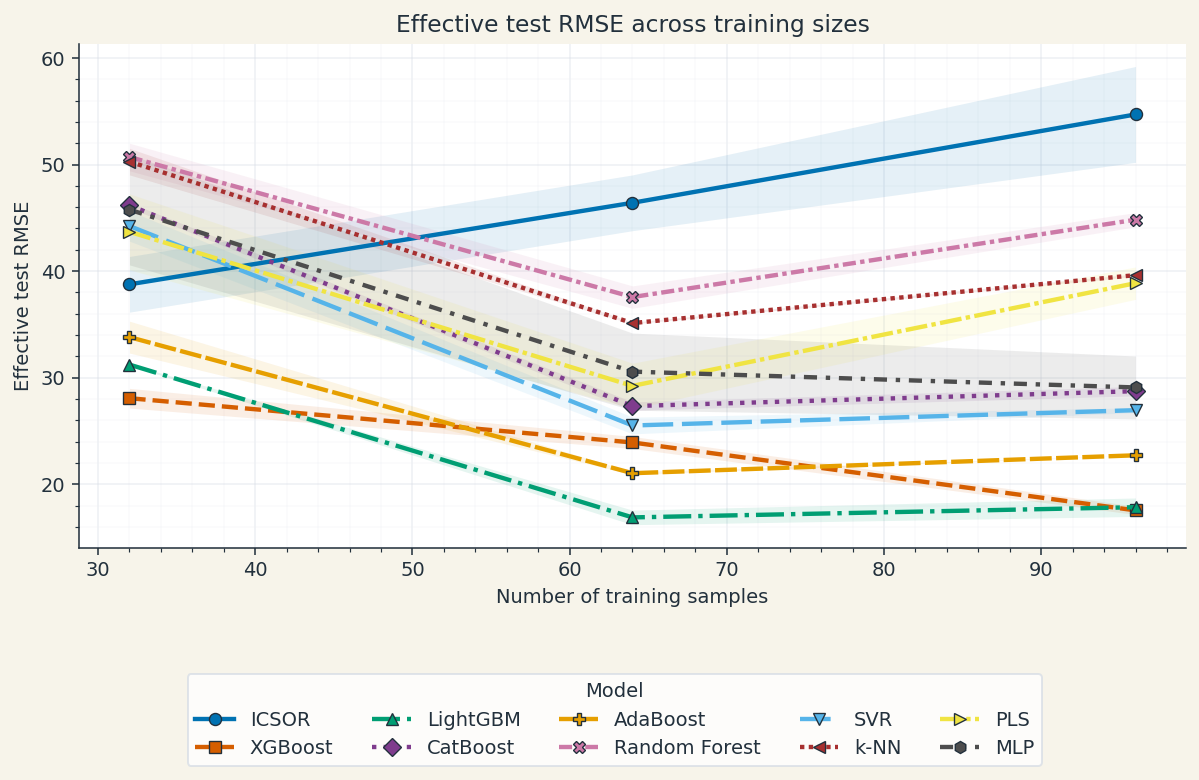

In [15]:
rmse_curve_plot_frame = rmse_learning_curve_summary.copy()
rmse_curve_plot_frame["model_label"] = pd.Categorical(
    rmse_curve_plot_frame["model_label"],
    categories=model_display_order,
    ordered=True,
)
rmse_curve_plot_frame = rmse_curve_plot_frame.sort_values(["model_label", "train_size"]).reset_index(drop=True)
rmse_curve_plot_frame["model_label"] = rmse_curve_plot_frame["model_label"].astype(str)

figure, axis = plot_metric_summary_lines(
    rmse_curve_plot_frame,
    x_column="train_size",
    y_column="metric_mean",
    group_column="model_label",
    lower_column="metric_q25",
    upper_column="metric_q75",
    title="Effective test RMSE across training sizes",
    x_label="Number of training samples",
    y_label="Effective test RMSE",
    legend_title="Model",
    figure_size=(10.2, 6.0),
    color_cycle=list(PIBRE_THEME_TOKENS["qualitative_cycle"]),
    marker_cycle=list(PIBRE_THEME_TOKENS["line_marker_cycle"]),
    linestyle_cycle=list(PIBRE_THEME_TOKENS["line_style_cycle"]),
    legend_outside=True,
    legend_location="bottom",
    legend_columns=5,
)

figure2_export_path = export_figure_pdf("figure2_rmse_learning_curve", figure)
ipython_display(figure)
plt.close(figure)

In [16]:
scaling_table_rounded = scaling_table.copy()
for column_name in ["Final RMSE", "RMSE nAUC", "Sample Avg. Rank", "Delta RMSE"]:
    scaling_table_rounded[column_name] = scaling_table_rounded[column_name].astype(float).round(4)

scaling_export_path = export_table_csv("table_results_scaling_sample", scaling_table_rounded, index=False)
ipython_display(scaling_table_rounded)

Saved table: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\table_results_scaling_sample.csv


,Model,Final RMSE,RMSE nAUC,Sample Avg. Rank,Delta RMSE
0,ICSOR,54.7049,46.5718,8.6833,54.6757
1,XGBoost,17.5427,23.3614,4.6333,17.4686
2,LightGBM,17.8398,20.7072,3.9667,16.5422
3,CatBoost,28.7305,32.3906,5.0833,28.4407
4,AdaBoost,22.7114,24.6443,4.3167,12.9862
5,Random Forest,44.8226,42.6638,7.2333,33.7004
6,SVR,26.9461,30.5487,3.9167,18.1452
7,k-NN,39.6214,40.0353,6.4833,39.5922
8,PLS,38.8694,35.2522,5.4000,10.8652
9,MLP,29.0811,33.9958,5.2833,9.9806


Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figure3_runtime_learning_curve.pdf


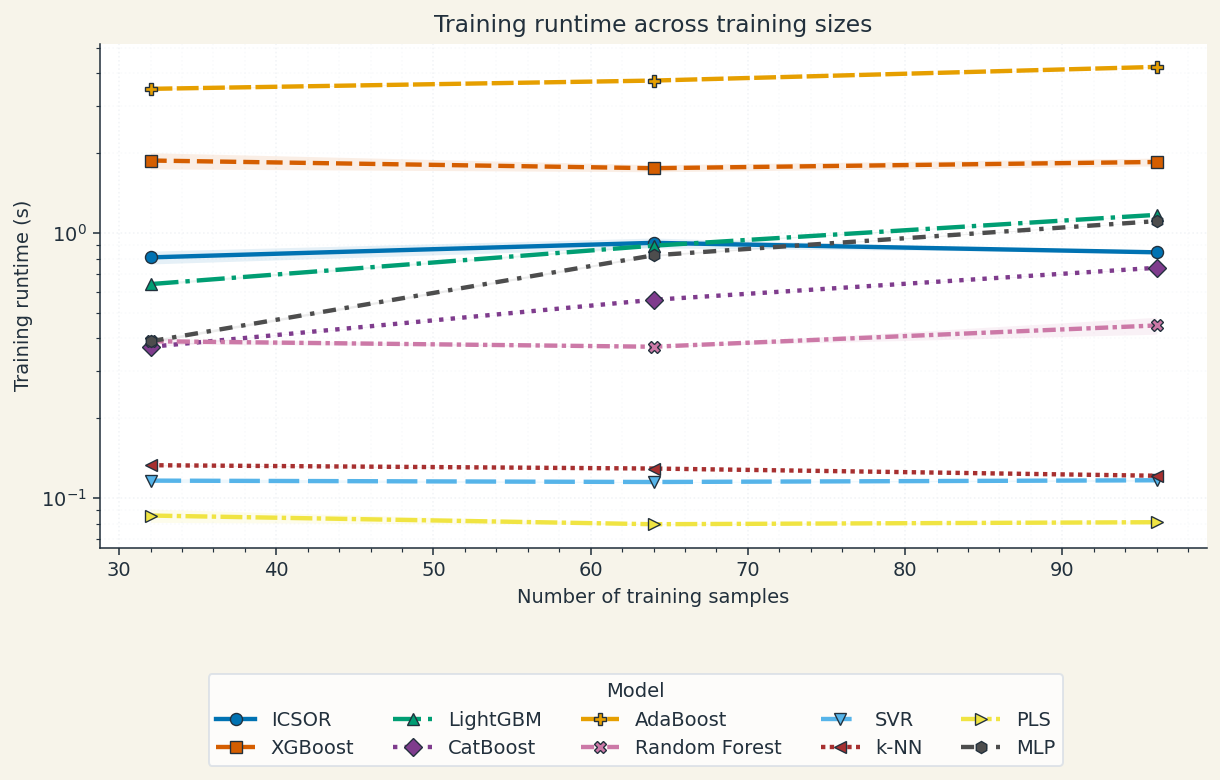

In [17]:
runtime_rows = []
for model_name, spec in retained_model_specs.items():
    model_runtime = analysis_results_by_model[model_name]["run_metadata"].copy()
    runtime_rows.append(
        model_runtime.assign(
            model_name=model_name,
            model_label=spec["label"],
            model_family=spec["family"],
        )
    )

runtime_frame = pd.concat(runtime_rows, ignore_index=True)
runtime_summary = summarize_metric_distribution(
    runtime_frame,
    metric_name="elapsed_seconds",
    group_columns=["model_name", "model_label", "model_family", "train_size"],
)
runtime_summary["model_label"] = pd.Categorical(
    runtime_summary["model_label"],
    categories=model_display_order,
    ordered=True,
)
runtime_summary = runtime_summary.sort_values(["model_label", "train_size"]).reset_index(drop=True)
runtime_summary["model_label"] = runtime_summary["model_label"].astype(str)

figure, axis = plot_metric_summary_lines(
    runtime_summary,
    x_column="train_size",
    y_column="metric_mean",
    group_column="model_label",
    lower_column="metric_q25",
    upper_column="metric_q75",
    title="Training runtime across training sizes",
    x_label="Number of training samples",
    y_label="Training runtime (s)",
    legend_title="Model",
    figure_size=(10.2, 6.0),
    color_cycle=list(PIBRE_THEME_TOKENS["qualitative_cycle"]),
    marker_cycle=list(PIBRE_THEME_TOKENS["line_marker_cycle"]),
    linestyle_cycle=list(PIBRE_THEME_TOKENS["line_style_cycle"]),
    legend_outside=True,
    legend_location="bottom",
    legend_columns=5,
)
axis.set_yscale("log")
axis.grid(True, which="both", linestyle=":", alpha=0.35)

figure3_export_path = export_figure_pdf("figure3_runtime_learning_curve", figure)
ipython_display(figure)
plt.close(figure)

In [18]:
physical_table_rounded = physical_table.copy()
for metric_column in ["Mass-Conservation Violations (%)", "Non-Negativity Violations (%)"]:
    physical_table_rounded[metric_column] = physical_table_rounded[metric_column].astype(float).round(4)

physical_export_path = export_table_csv("table_results_physical_sample", physical_table_rounded, index=False)
ipython_display(physical_table_rounded)

Saved table: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\table_results_physical_sample.csv


,Model,Mass-Conservation Violations (%),Non-Negativity Violations (%)
0,ICSOR,0.0,0.0000
1,XGBoost,0.0,58.3333
2,LightGBM,0.0,58.3333
3,CatBoost,0.0,50.0000
4,AdaBoost,0.0,25.0000
5,Random Forest,0.0,54.1667
6,SVR,0.0,58.3333
7,k-NN,0.0,62.5000
8,PLS,0.0,70.8333
9,MLP,0.0,83.3333


Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figure4_icsor_structure.pdf


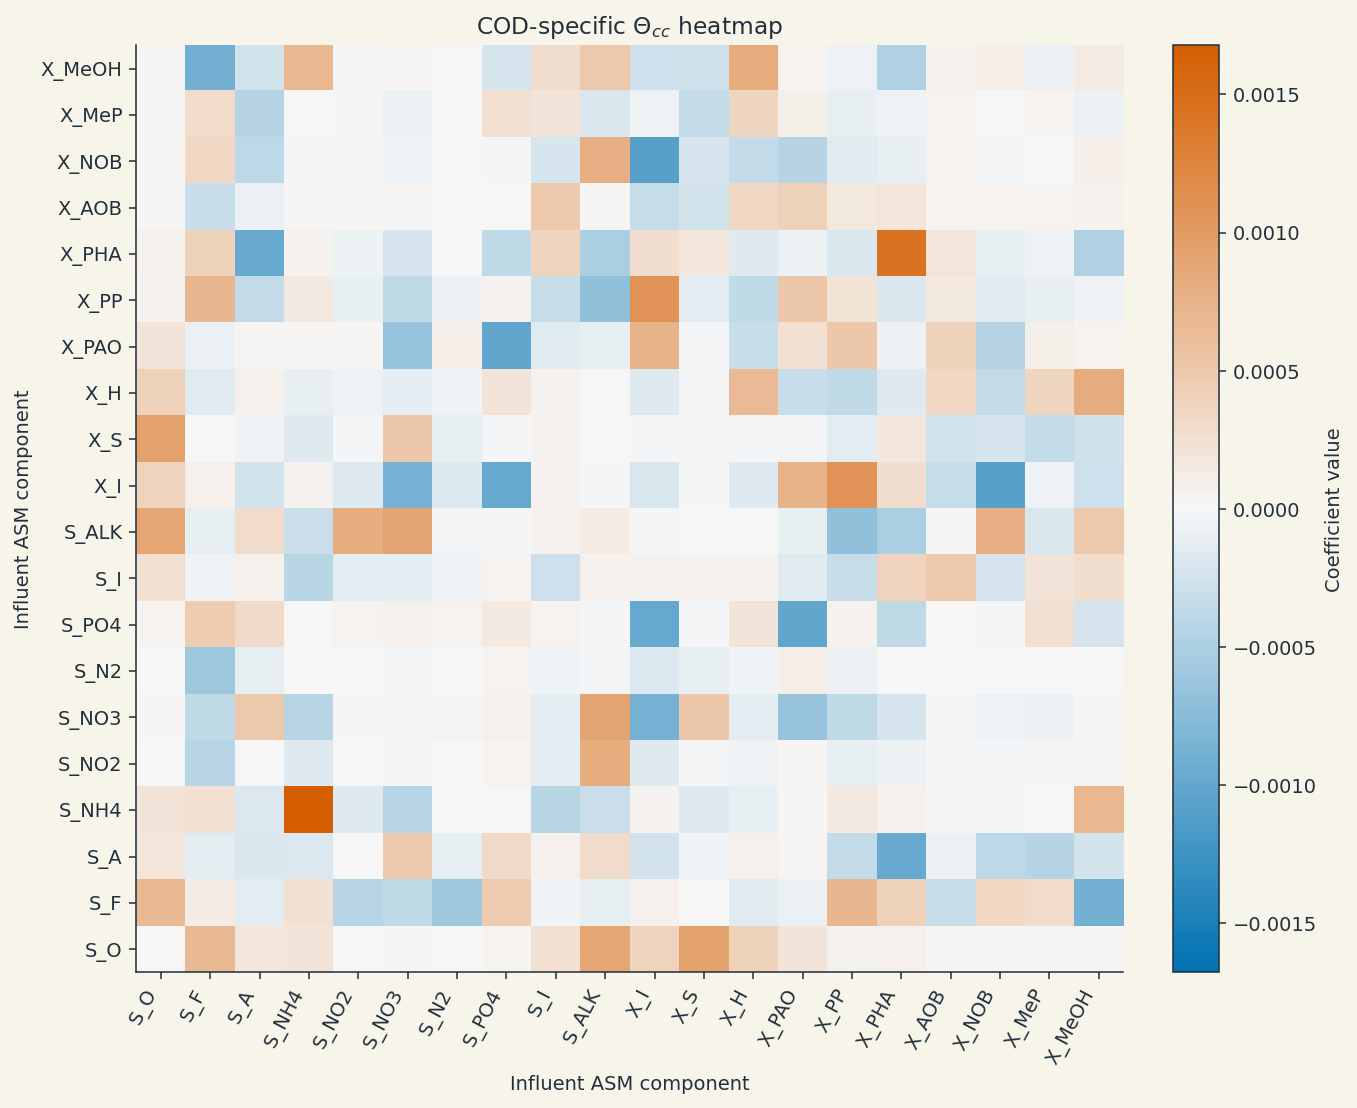

In [19]:
figure, axis = plot_coefficient_heatmap(
    theta_cc_cod,
    row_labels=state_columns,
    column_labels=state_columns,
    title=r"COD-specific $\Theta_{cc}$ heatmap",
    x_label="Influent ASM component",
    y_label="Influent ASM component",
    colorbar_label="Coefficient value",
    figure_size=(9.6, 7.8),
    x_tick_rotation=62.0,
)

figure4_export_path = export_figure_pdf("figure4_icsor_structure", figure)
ipython_display(figure)
plt.close(figure)

In [20]:
regularization_table_rounded = regularization_table.copy()
regularization_table_rounded["Total coeffs."] = regularization_table_rounded["Total coeffs."].astype(int)
regularization_table_rounded["Retained coeffs."] = regularization_table_rounded["Retained coeffs."].astype(int)
regularization_table_rounded["% Retained"] = regularization_table_rounded["% Retained"].astype(float).round(4)

regularization_export_path = export_table_csv("table_results_icsor_regularization_sample", regularization_table_rounded, index=False)
ipython_display(regularization_table_rounded)

Saved table: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\table_results_icsor_regularization_sample.csv


,Coefficient block,Total coeffs.,Retained coeffs.,% Retained
0,b,1,1,100.0
1,W_u,2,2,100.0
2,W_in,20,20,100.0
3,Theta_uu,4,4,100.0
4,Theta_uc,40,40,100.0
5,Theta_cc,400,400,100.0
6,Overall summary,467,467,100.0


Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figureS1_cod_icsor_structure.pdf


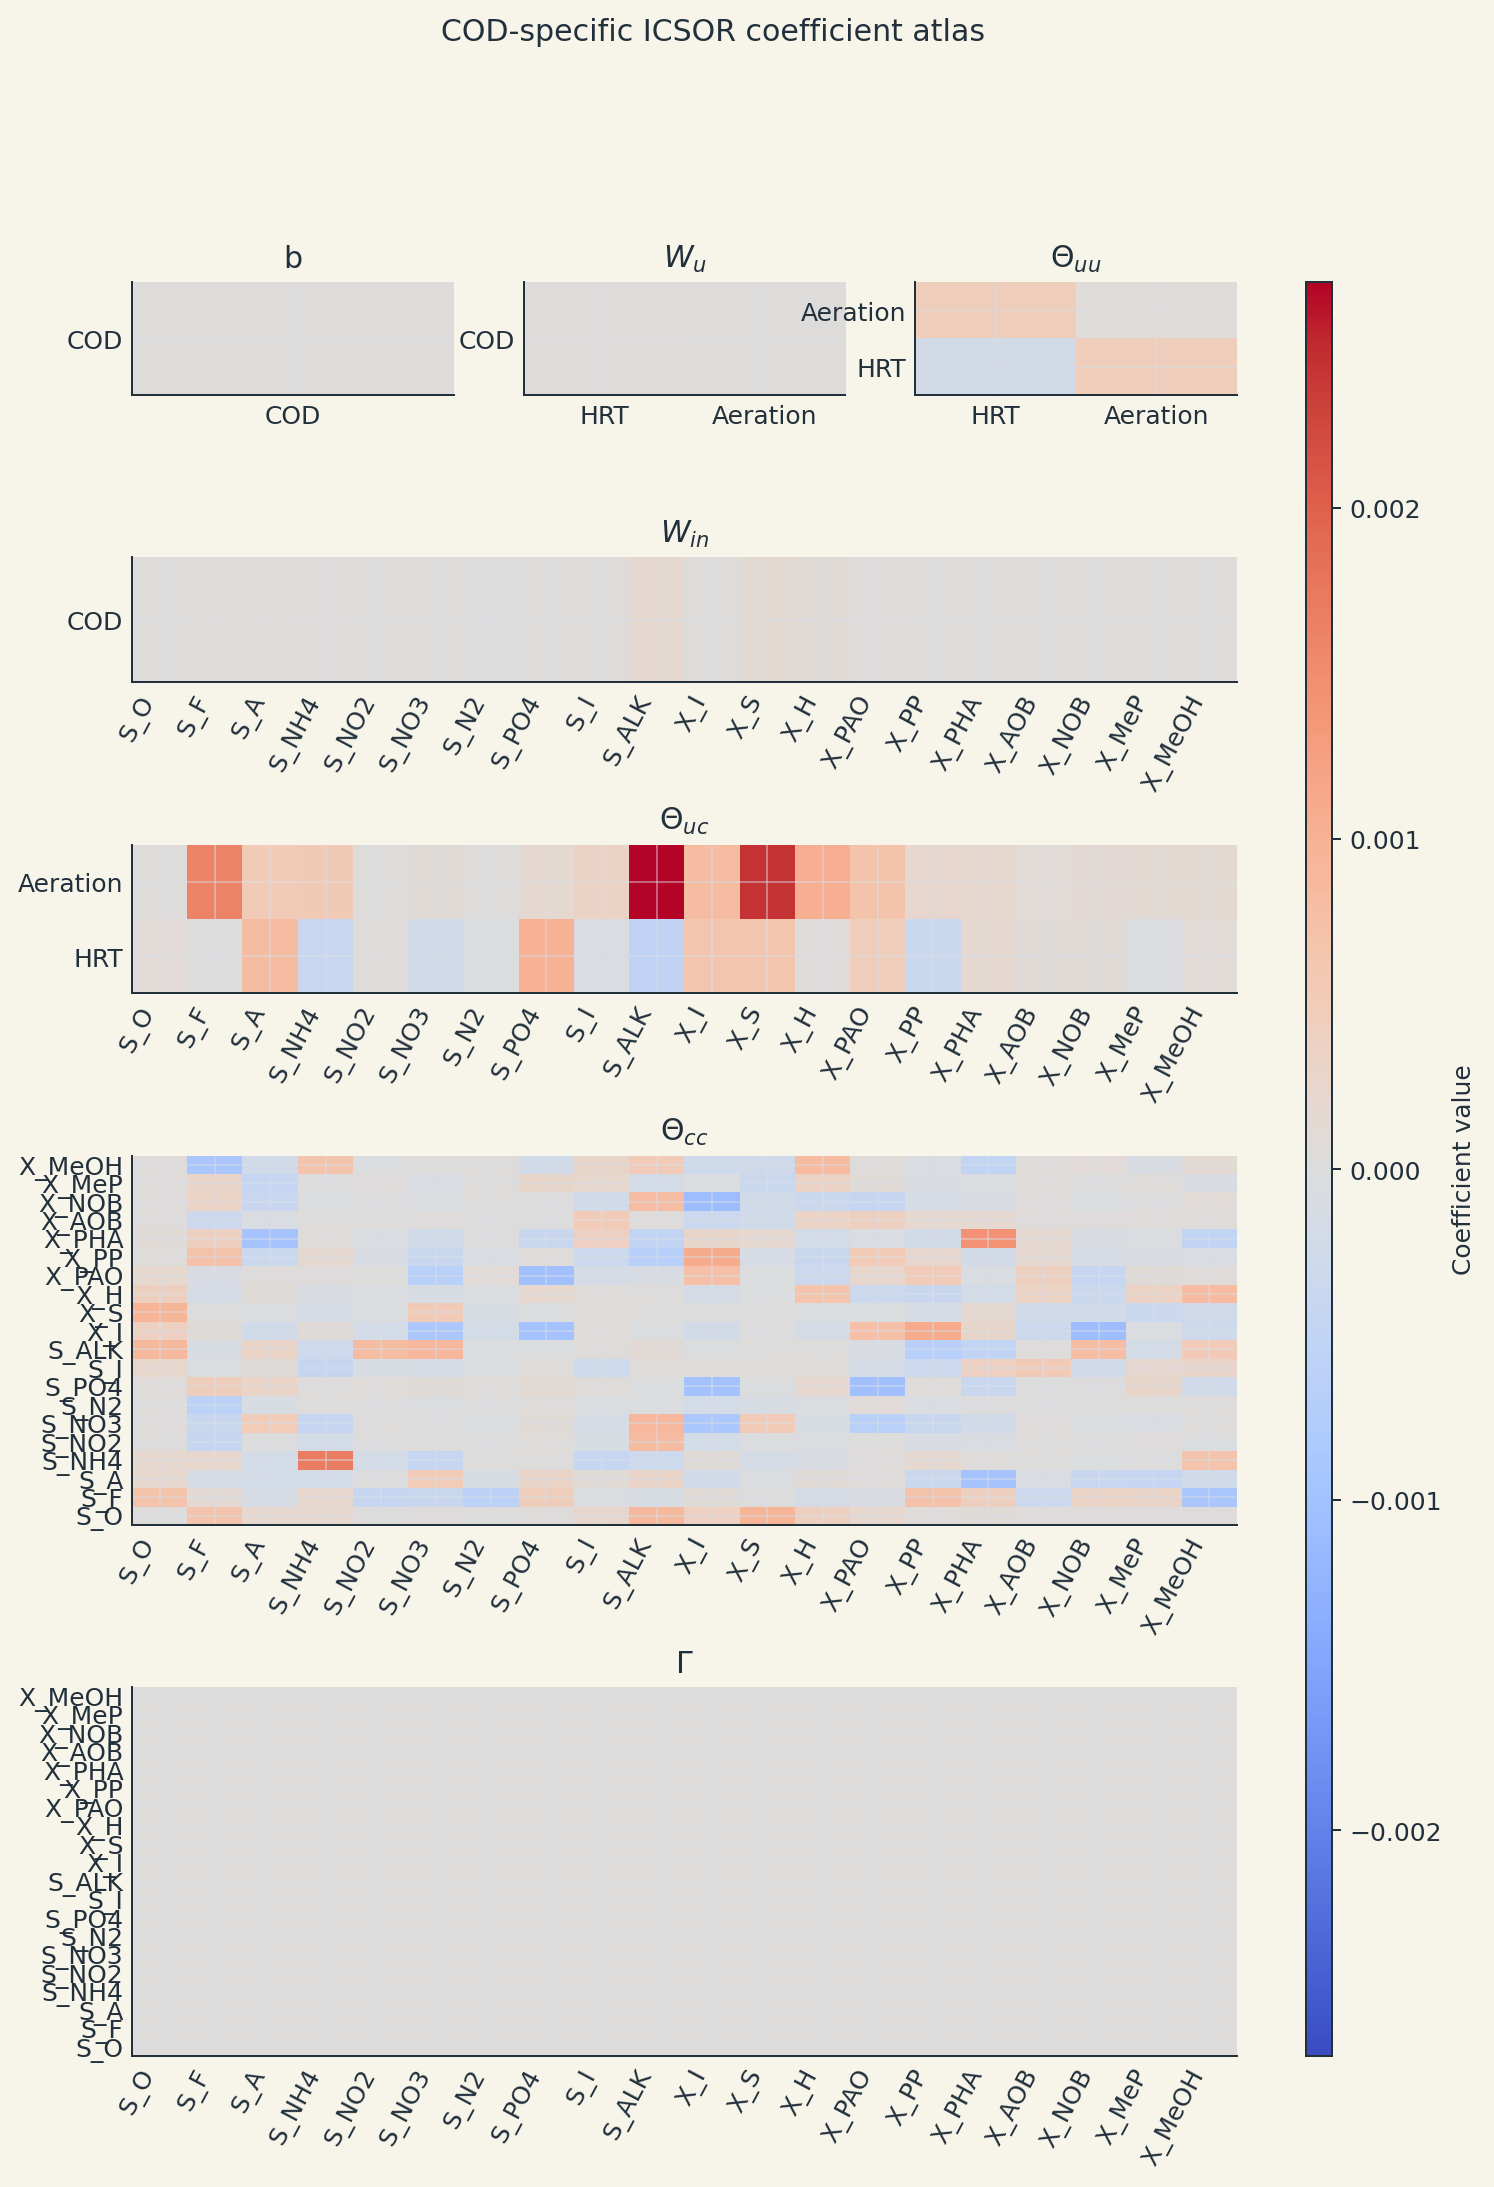

In [21]:
figure = plot_target_atlas("COD")
figureS1_export_path = export_figure_pdf("figureS1_cod_icsor_structure", figure)
ipython_display(figure)
plt.close(figure)

Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figureS2_tn_icsor_structure.pdf


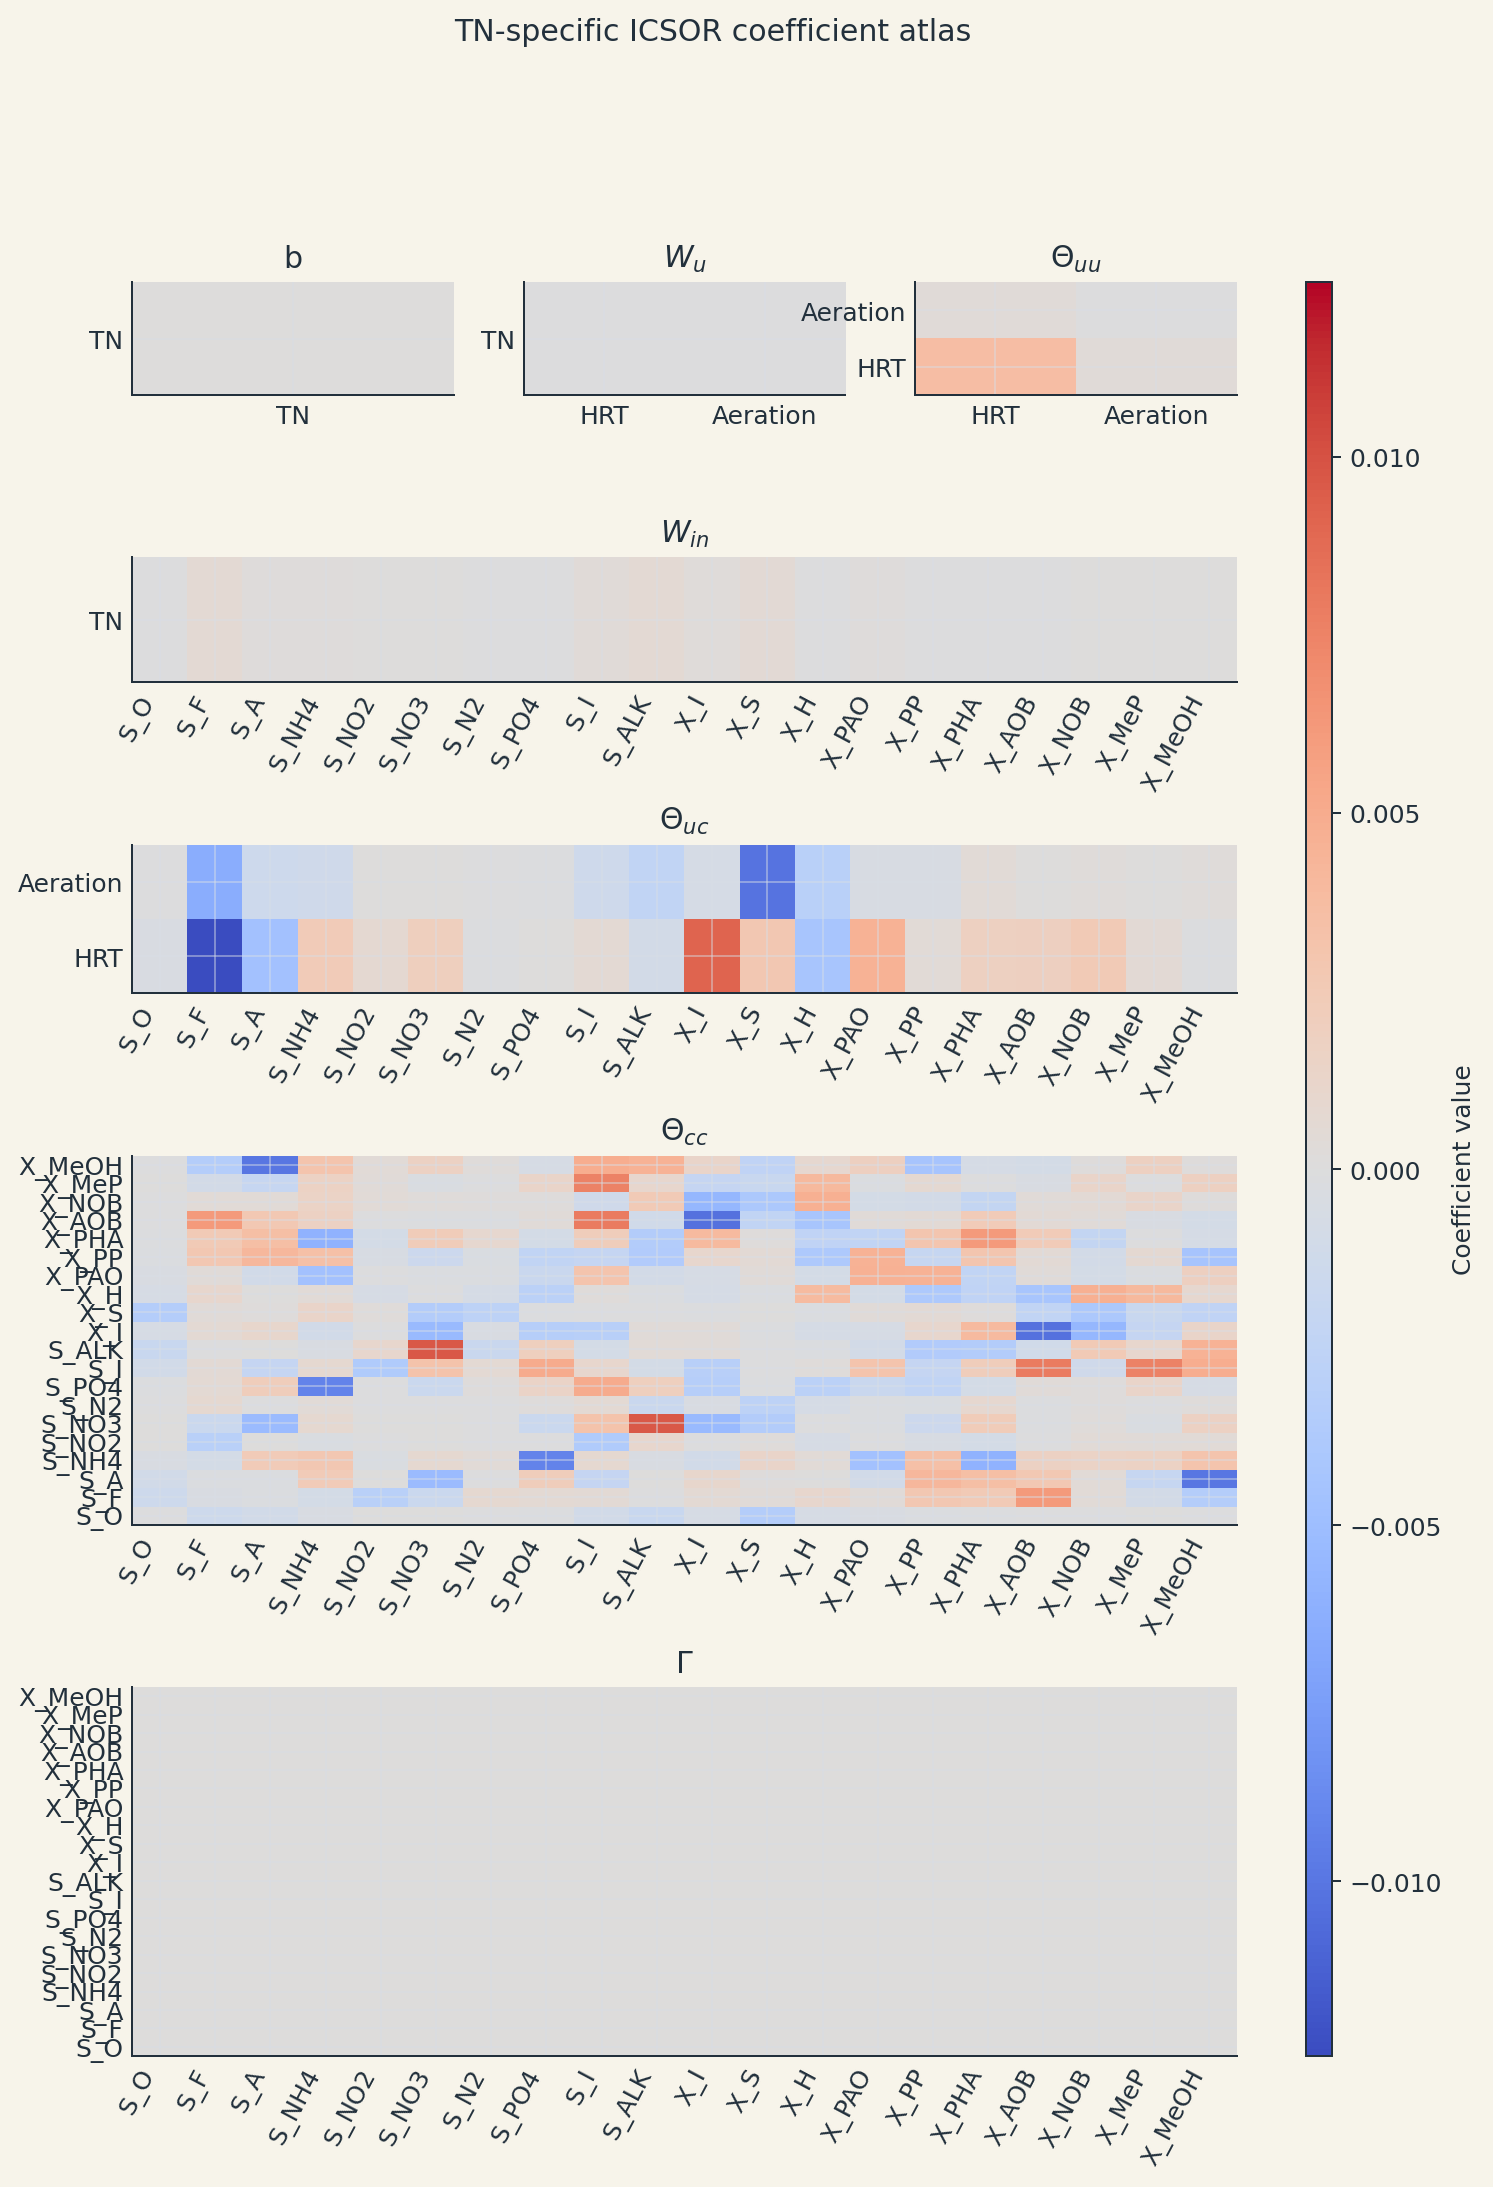

In [22]:
figure = plot_target_atlas("TN")
figureS2_export_path = export_figure_pdf("figureS2_tn_icsor_structure", figure)
ipython_display(figure)
plt.close(figure)

Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figureS3_tp_icsor_structure.pdf


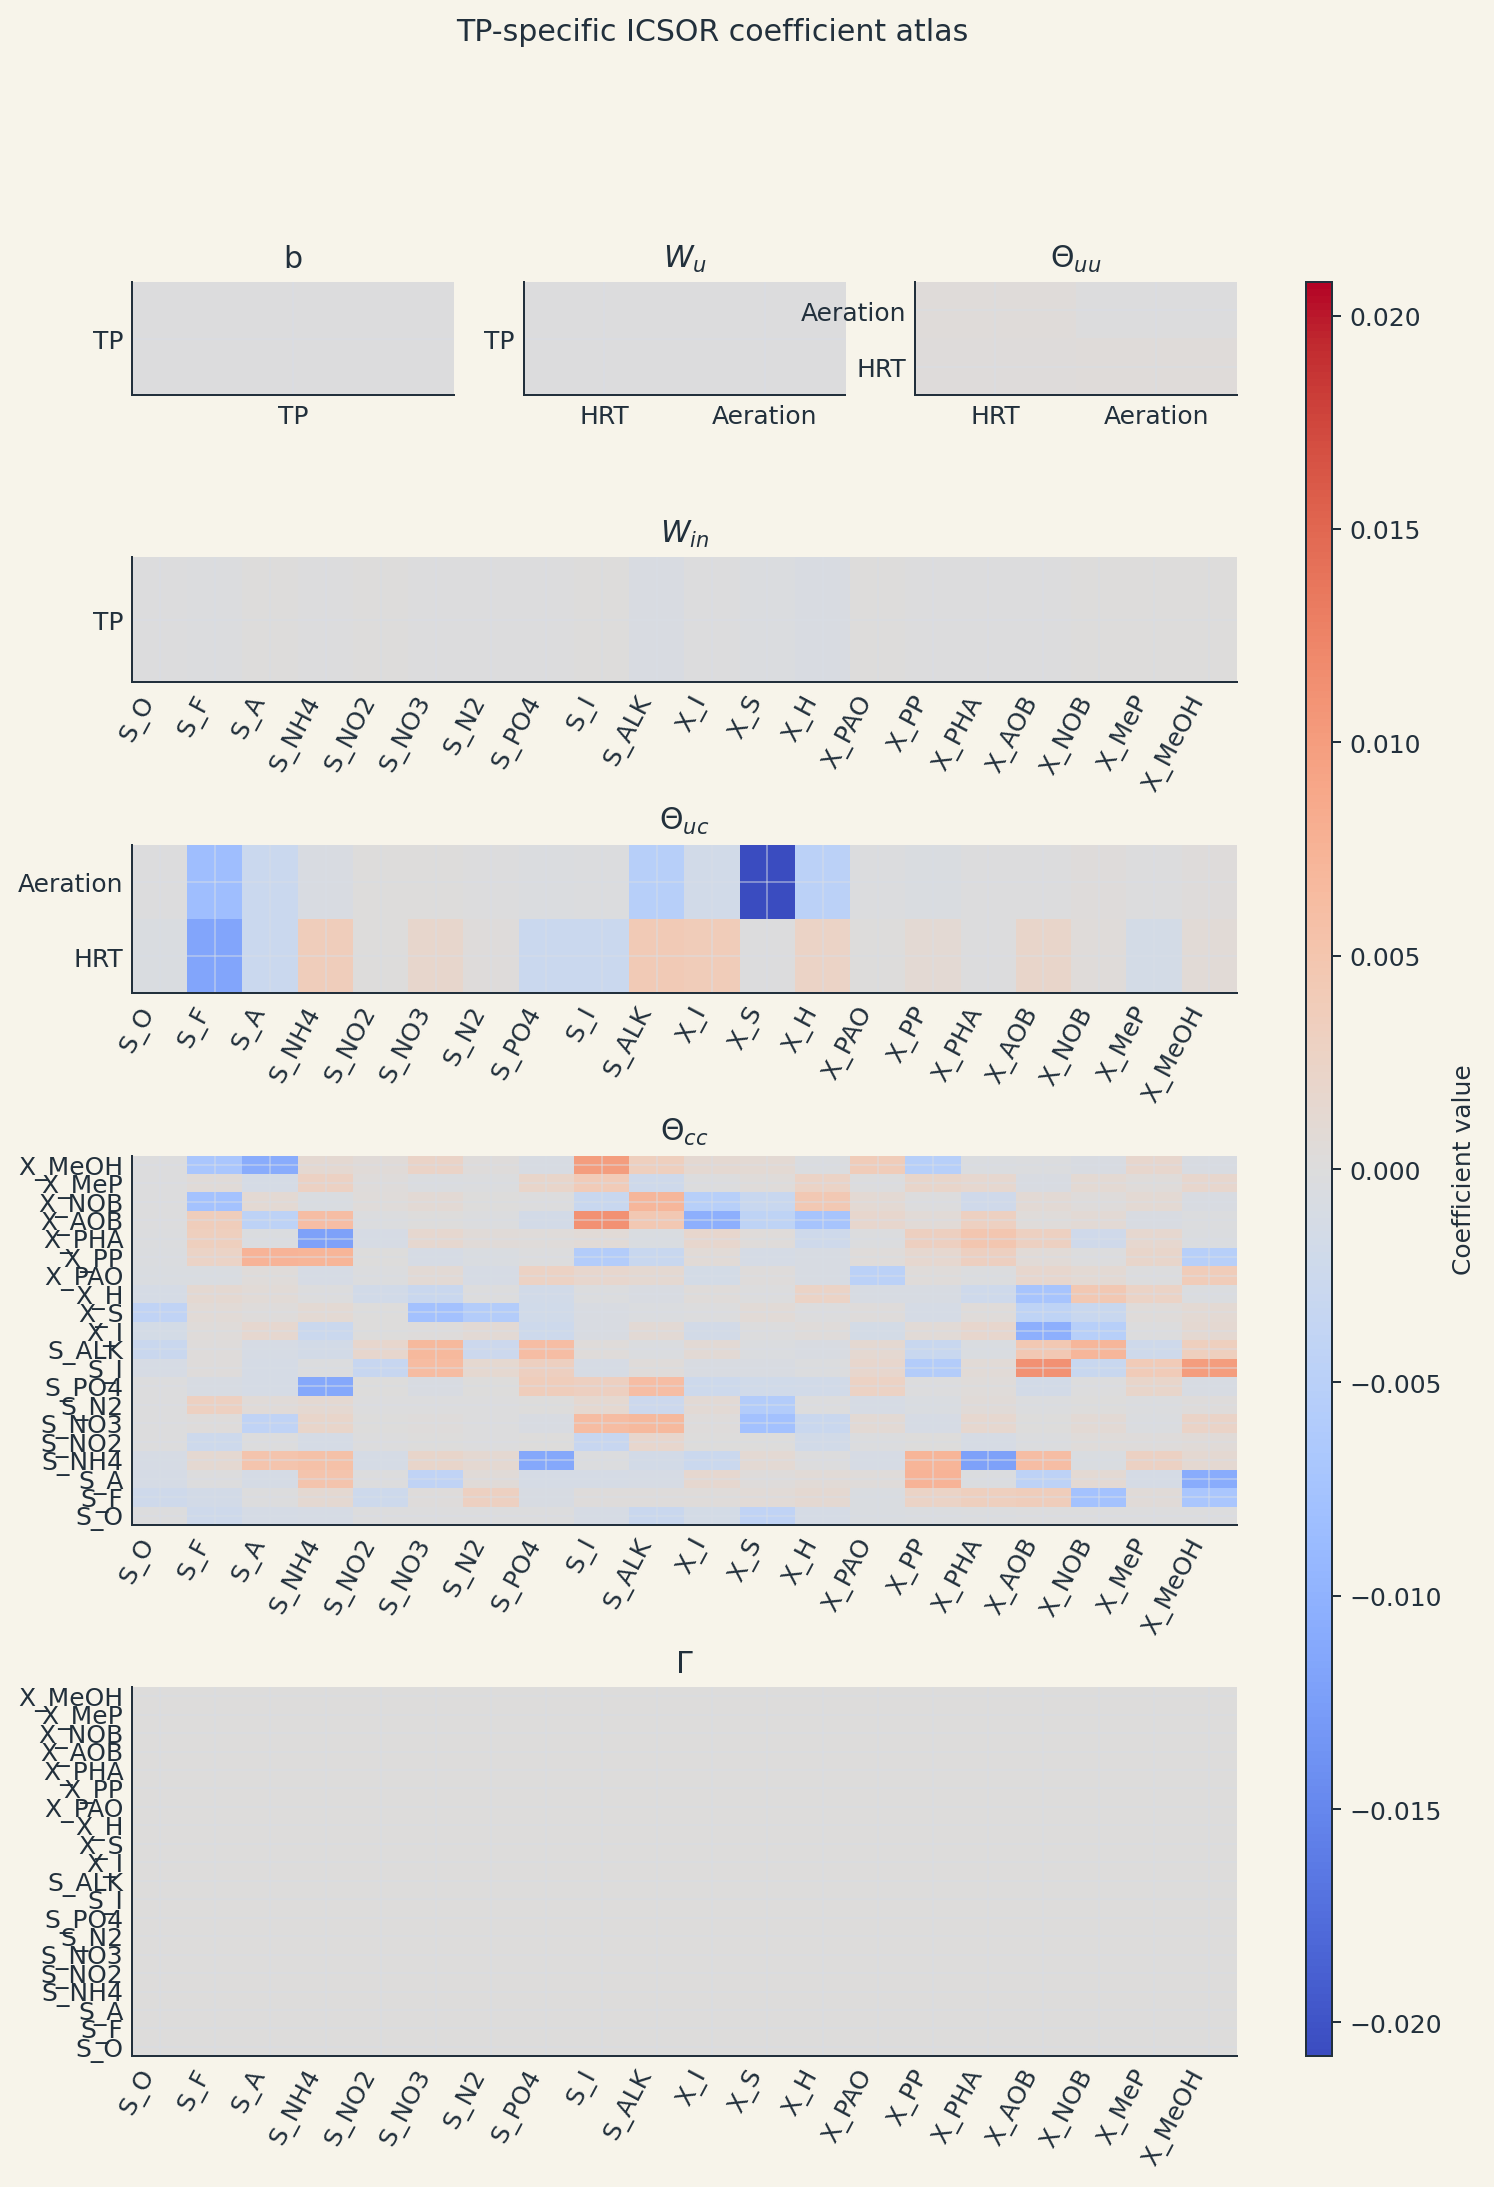

In [23]:
figure = plot_target_atlas("TP")
figureS3_export_path = export_figure_pdf("figureS3_tp_icsor_structure", figure)
ipython_display(figure)
plt.close(figure)

Saved figure: C:\Users\eselerio\projects\pibre-model\docs\DCHE-D-26-00020\figureS4_tss_icsor_structure.pdf


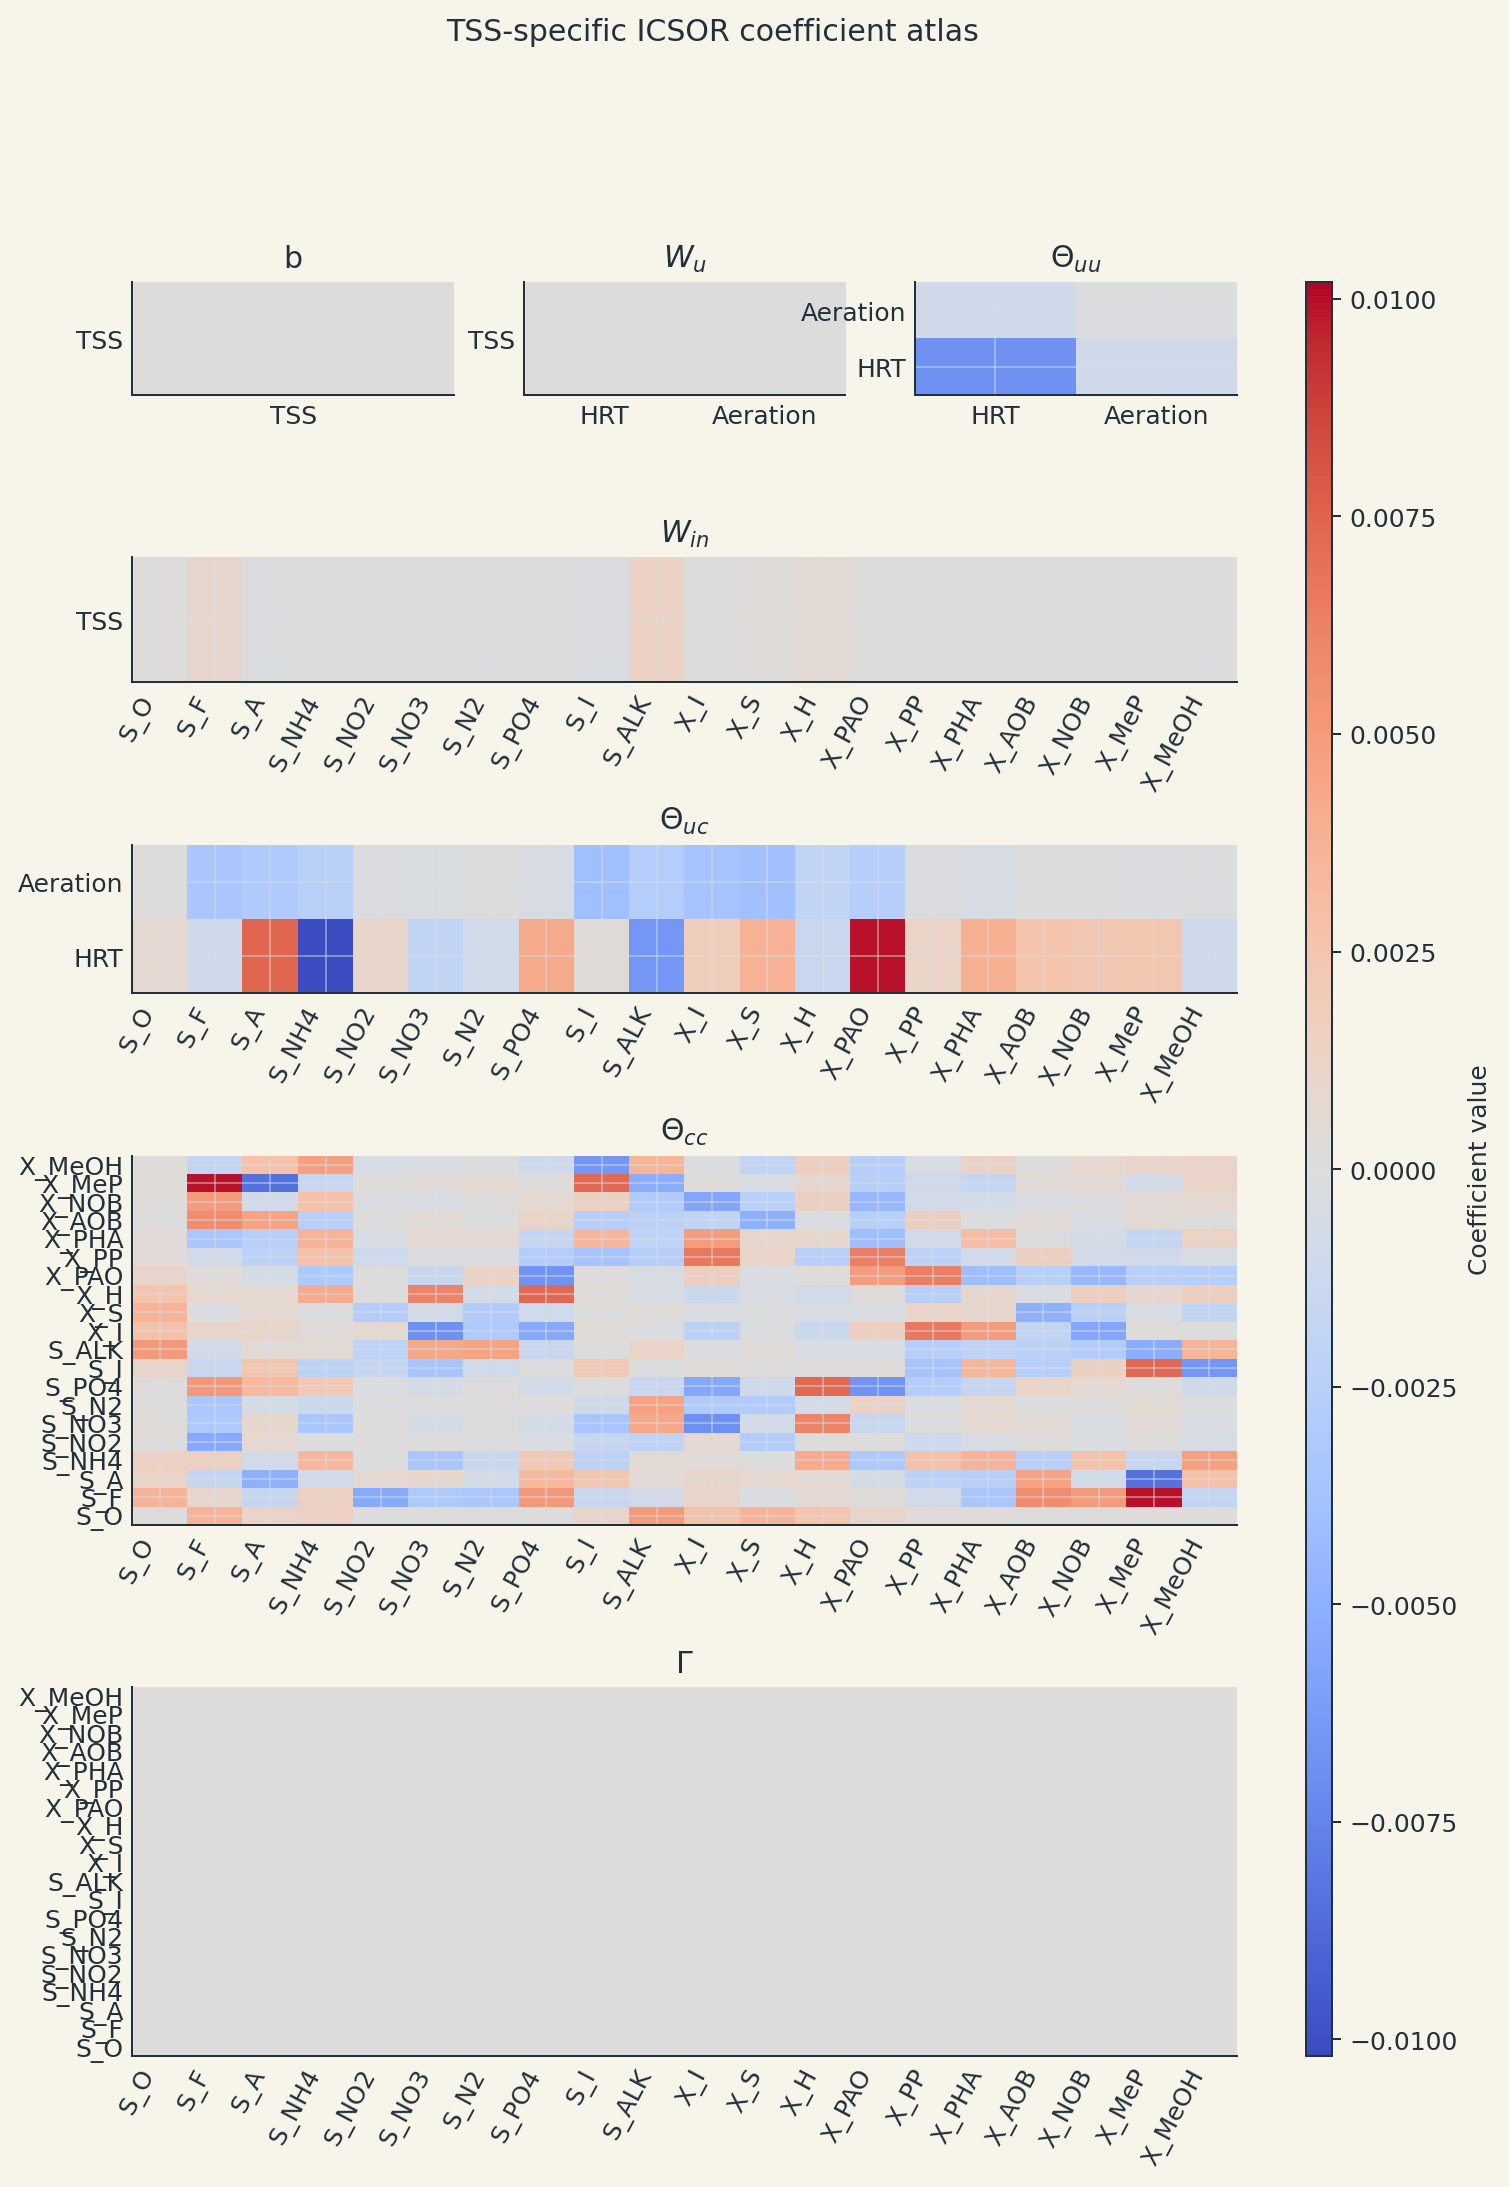

In [24]:
figure = plot_target_atlas("TSS")
figureS4_export_path = export_figure_pdf("figureS4_tss_icsor_structure", figure)
ipython_display(figure)
plt.close(figure)

In [25]:
expected_asset_paths = [submission_asset_dir / asset_name for asset_name in required_assets]
asset_status = pd.DataFrame(
    {
        "asset": [path.name for path in expected_asset_paths],
        "exists": [path.exists() for path in expected_asset_paths],
        "path": [str(path) for path in expected_asset_paths],
    }
)

print("Comparison notebook data provenance:")
print(f"- Dataset CSV: {artifact_paths['dataset_csv']}")
print(f"- Metadata JSON: {artifact_paths['metadata_json']}")
print(f"- Matrix source: {matrix_bundle['composition_workbook_path']}")
print(f"- Composition cache source: {matrix_bundle['composition_cache_source']}")

if any("/results/" in str(path).replace("\\", "/") for path in expected_asset_paths):
    raise RuntimeError("One or more export targets point to the results directory, which is not allowed.")

print("Asset existence check:")
ipython_display(asset_status)
if not bool(asset_status["exists"].all()):
    missing_assets = asset_status.loc[~asset_status["exists"], "asset"].tolist()
    raise FileNotFoundError(f"Missing exported assets: {missing_assets}")

print("All expected manuscript and supplementary assets are present in docs/DCHE-D-26-00020.")

Comparison notebook data provenance:
- Dataset CSV: C:\Users\eselerio\projects\pibre-model\data\asm2d-tsn\simulation\data_20260422_120000.csv
- Metadata JSON: C:\Users\eselerio\projects\pibre-model\data\asm2d-tsn\simulation\metadata_20260422_120000.json
- Matrix source: C:/Users/eselerio/projects/pibre-model/data/asm2d-tsn/asm2d_tsn_workbook.xlsx
- Composition cache source: cache
Asset existence check:


,asset,exists,path
0,table_results_benchmark_sample.csv,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
1,table_results_target_sample.csv,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
2,figure2_rmse_learning_curve.pdf,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
3,table_results_scaling_sample.csv,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
4,figure3_runtime_learning_curve.pdf,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
5,table_results_physical_sample.csv,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
6,figure4_icsor_structure.pdf,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
7,table_results_icsor_regularization_sample.csv,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
8,figureS1_cod_icsor_structure.pdf,True,C:\Users\eselerio\projects\pibre-model\docs\DC...
9,figureS2_tn_icsor_structure.pdf,True,C:\Users\eselerio\projects\pibre-model\docs\DC...


All expected manuscript and supplementary assets are present in docs/DCHE-D-26-00020.
